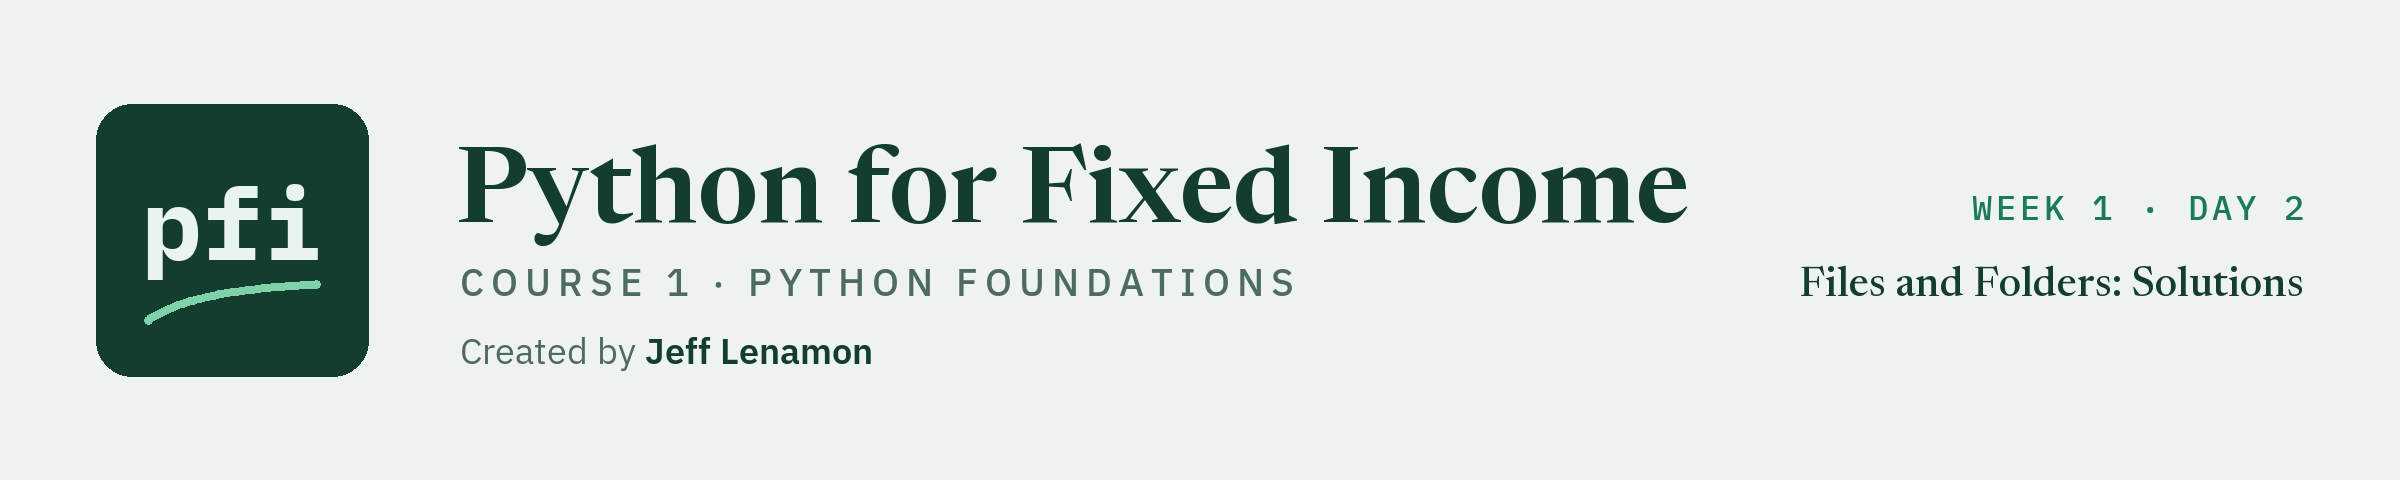

# Files and Folders - Solutions

Week 1. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week1/day2/02_files_and_folders_solutions.ipynb)

## Exercises

A second desk records its trades. Today it bought three bonds. The issuers are invented.

| Ticker | Face bought | Price |
| --- | --- | --- |
| TRNW | 2,000,000 | 96.25 |
| OSMC | 1,250,000 | 100.00 |
| CLDB | 500,000 | 104.50 |

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next two cells first. The first defines `check`, which marks your answers. The second removes anything left over from an earlier attempt.

In [1]:
def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
    elif answer == expected:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)

In [2]:
import os
import shutil

# remove anything left over from an earlier attempt
for folder in ['blotter', 'trade_blotter']:
    shutil.rmtree(folder, ignore_errors=True)
if os.path.exists('ai_holdings.csv'):
    os.remove('ai_holdings.csv')

### Exercise 1

Q. Create a folder named 'blotter'. Then store whether it exists in **ex1_exists**.

In [3]:
# create the folder
os.mkdir('blotter')
# check that it is there
ex1_exists = os.path.exists('blotter')
print(ex1_exists)

True


In [4]:
check('Exercise 1', ex1_exists, True)

Exercise 1: correct


### Exercise 2

Q. Write a file named 'trades.csv' inside the 'blotter' folder. It should have the header line `Ticker,Face,Price` and one line for each of the three trades. Then read it back and store the number of lines in **ex2_line_count**.

In [5]:
# build the path to the file
trades_path = os.path.join('blotter', 'trades.csv')
# write the header and the three trades
with open(trades_path, 'w', encoding='utf-8') as file:
    file.write('Ticker,Face,Price\n')
    file.write('TRNW,2000000,96.25\n')
    file.write('OSMC,1250000,100.0\n')
    file.write('CLDB,500000,104.5\n')

# read the lines back
with open(trades_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()

ex2_line_count = len(lines)
print(ex2_line_count)

4


In [6]:
check('Exercise 2', ex2_line_count, 4)

Exercise 2: correct


### Exercise 3

Q. Read 'trades.csv' and work out the total cost of the three trades. The cost of a trade is face times price divided by 100. That is the cost at the clean price, with accrued interest left out. Store the answer in **ex3_total_cost**.

In [7]:
# start a running total at zero
ex3_total_cost = 0
# skip the header line
for line in lines[1:]:
    values = line.strip().split(',')
    # convert the strings to numbers before doing arithmetic
    face = int(values[1])
    price = float(values[2])
    ex3_total_cost = ex3_total_cost + face * price / 100

print('The trades cost $', ex3_total_cost, sep='')

The trades cost $3697500.0


* The face and price come out of the file as strings. `int()` and `float()` turn them into numbers first.

In [8]:
check('Exercise 3', ex3_total_cost, 3697500.0)

Exercise 3: correct


### Exercise 4

Q. Rename the 'blotter' folder to 'trade_blotter'. Then store the list of files inside it in **ex4_files**.

In [9]:
# rename takes the old name, then the new name
os.rename('blotter', 'trade_blotter')
# the file moved with its folder
ex4_files = os.listdir('trade_blotter')
print(ex4_files)

['trades.csv']


In [10]:
check('Exercise 4', ex4_files, ['trades.csv'])

Exercise 4: correct


### Exercise 5

Q. Use `pathlib` to build the path to 'trades.csv' inside the 'trade_blotter' folder from Exercise 4. Store whether the file exists in **ex5_exists**, and the name of the folder it sits in in **ex5_folder**.

In [11]:
from pathlib import Path

# the / operator joins the folder and the file name
trades_path = Path('trade_blotter') / 'trades.csv'
# exists() is a method of the path
ex5_exists = trades_path.exists()
# parent is the folder the file sits in, and name is the last part of that folder's path
ex5_folder = trades_path.parent.name
print(f'{trades_path.name} exists: {ex5_exists}')
print(f'It sits in the folder {ex5_folder}')

trades.csv exists: True
It sits in the folder trade_blotter


In [12]:
check('Exercise 5 exists', ex5_exists, True)
check('Exercise 5 folder', ex5_folder, 'trade_blotter')

Exercise 5 exists: correct
Exercise 5 folder: correct


### Exercise 6

Q. Read 'trades.csv' in the 'trade_blotter' folder with `csv.DictReader` and total the Face column. Store the total in **ex6_total_face**.

In [13]:
import csv

# start a running total at zero
ex6_total_face = 0
with open(trades_path, 'r', encoding='utf-8', newline='') as file:
    # each row is a dictionary keyed by the header line
    for row in csv.DictReader(file):
        # the face is text in the file, so convert it before adding
        ex6_total_face = ex6_total_face + int(row['Face'])

print(f'The total face bought is {ex6_total_face:,}')

The total face bought is 3,750,000


* The face is read by its column name, so this code would still work if the Price column came before the Face column. `open()` accepted the `Path` from Exercise 5 as it would a string.

In [14]:
check('Exercise 6', ex6_total_face, 3750000)

Exercise 6: correct


### Exercise 7: AI check

You ask an AI assistant for code that creates a small holdings file and then adds one more bond to it. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug.

Q. Read the code before you run it. A header, three bonds, and one more bond: how many lines should the file have? Then run it.

In [15]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# create the file with a header and three bonds
with open('ai_holdings.csv', 'w', encoding='utf-8') as file:
    file.write('Ticker,Face\n')
    file.write('TRNW,2000000\n')
    file.write('OSMC,1250000\n')
    file.write('CLDB,500000\n')

# add one more bond to the file
with open('ai_holdings.csv', 'w', encoding='utf-8') as file:
    file.write('QVNE,1500000\n')

# count the lines in the file
with open('ai_holdings.csv', 'r', encoding='utf-8') as file:
    print('Lines in the file:', len(file.readlines()))

Lines in the file: 1


Q. Find the bug. Then fix the code so the file ends up with every line it should have, and store the number of lines in **ex7_line_count**.

* The file should have 5 lines: a header, three bonds, and the added bond. The code prints 1.
* The bug is the second `open()`. It uses `'w'`, which wipes the file before writing. To add to a file and keep what is there, the mode has to be `'a'` for append.
* There was no error. The only sign of trouble was a number that did not match what we expected.

In [16]:
# create the file with a header and three bonds
with open('ai_holdings.csv', 'w', encoding='utf-8') as file:
    file.write('Ticker,Face\n')
    file.write('TRNW,2000000\n')
    file.write('OSMC,1250000\n')
    file.write('CLDB,500000\n')

# add one more bond, this time in append mode
with open('ai_holdings.csv', 'a', encoding='utf-8') as file:
    file.write('QVNE,1500000\n')

# count the lines in the file
with open('ai_holdings.csv', 'r', encoding='utf-8') as file:
    ex7_line_count = len(file.readlines())

print('Lines in the file:', ex7_line_count)

Lines in the file: 5


In [17]:
check('Exercise 7', ex7_line_count, 5)

Exercise 7: correct


When you are finished, run this cell to remove the folders and files the exercises created.

In [18]:
for folder in ['blotter', 'trade_blotter']:
    shutil.rmtree(folder, ignore_errors=True)
if os.path.exists('ai_holdings.csv'):
    os.remove('ai_holdings.csv')